In [1]:
import os
from glob import glob

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt



In [2]:
# =====================
# Paths
# =====================
wd_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

# =====================
# Load REZ mask
# =====================
rez = xr.open_dataset(rez_file)["rez_mask"]

rez_valid = np.isfinite(rez)



In [3]:
# =====================
# Event extraction
# =====================
def event_durations_1d(mask):

    mask = np.asarray(mask, dtype=np.int8)

    padded = np.pad(
        mask,
        (1,1),
        mode="constant",
        constant_values=0
    )

    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends   = np.where(changes == -1)[0]

    durations = ends - starts

    return durations.tolist()



In [4]:
# =====================
# Collect all events
# =====================
all_durations = []

files = sorted(
    glob(
        os.path.join(
            wd_dir,
            "wind_drought_P20_3day_*.nc"
        )
    )
)

for fp in files:

    print(
        f"Processing {os.path.basename(fp)}",
        flush=True
    )

    wd = xr.open_dataset(fp)["wind_drought"]

    # match REZ grid
    wd = wd.sel(
        latitude=rez.latitude,
        longitude=rez.longitude
    )

    wd = wd.where(rez_valid)

    arr = wd.fillna(0).values

    nt, ny, nx = arr.shape

    arr = arr.reshape(
        nt,
        ny*nx
    )

    for i in range(arr.shape[1]):

        durations = event_durations_1d(
            arr[:,i]
        )

        all_durations.extend(
            durations
        )



Processing wind_drought_P20_3day_1990.nc
Processing wind_drought_P20_3day_1991.nc
Processing wind_drought_P20_3day_1992.nc
Processing wind_drought_P20_3day_1993.nc
Processing wind_drought_P20_3day_1994.nc
Processing wind_drought_P20_3day_1995.nc
Processing wind_drought_P20_3day_1996.nc
Processing wind_drought_P20_3day_1997.nc
Processing wind_drought_P20_3day_1998.nc
Processing wind_drought_P20_3day_1999.nc
Processing wind_drought_P20_3day_2000.nc
Processing wind_drought_P20_3day_2001.nc
Processing wind_drought_P20_3day_2002.nc
Processing wind_drought_P20_3day_2003.nc
Processing wind_drought_P20_3day_2004.nc
Processing wind_drought_P20_3day_2005.nc
Processing wind_drought_P20_3day_2006.nc
Processing wind_drought_P20_3day_2007.nc
Processing wind_drought_P20_3day_2008.nc
Processing wind_drought_P20_3day_2009.nc
Processing wind_drought_P20_3day_2010.nc
Processing wind_drought_P20_3day_2011.nc
Processing wind_drought_P20_3day_2012.nc
Processing wind_drought_P20_3day_2013.nc
Processing wind_

In [5]:
# =====================
# Convert to numpy
# =====================
all_durations = np.array(
    all_durations
)

print(
    "Number of events:",
    len(all_durations)
)

print(
    "Mean duration:",
    np.mean(all_durations)
)

print(
    "Median duration:",
    np.median(all_durations)
)

print(
    "95th percentile:",
    np.percentile(
        all_durations,
        95
    )
)

Number of events: 284499
Mean duration: 3.8137638445126343
Median duration: 3.0
95th percentile: 6.0


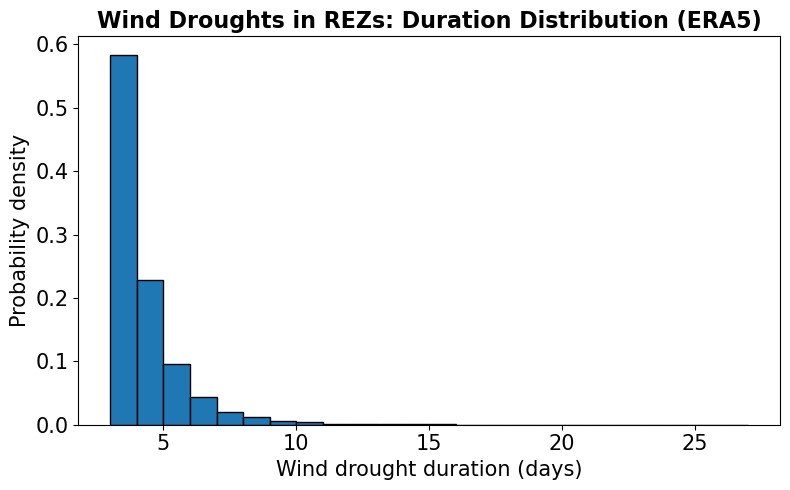

In [10]:
plt.figure(
    figsize=(8,5)
)

bins = np.arange(
    3,
    np.max(all_durations)+2
)

plt.hist(
    all_durations,
    bins=bins,
    density=True,
    edgecolor="black"
)

# x-y tickmarks fontsize
plt.xticks(
    fontsize=15
)
plt.yticks(
    fontsize=15
)

plt.xlabel(
    "Wind drought duration (days)",fontsize=15
)

plt.ylabel(
    "Probability density",fontsize=15
)

plt.title(
    "Wind Droughts in REZs: Duration Distribution (ERA5)", fontsize=16, fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "REZ_wind_drought_duration_distribution.png",
    dpi=300
)

plt.show()